# Introduction to Computational Physics: Problem Set 4
Tutorial: Chun Ming Yip (Group 3)

Document created by: Vencel Szabó, Finn Zeumer

# Libaries

'Papulator' can be found under https://github.com/FinnZeumer/Papulator

By adding the _normal_ python file into the same folder as this protkect, the code will work rigth away.

In [128]:
# Libaries
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
import pandas as pd
import time
 # Custom Libary from other project
import Papulator as pap
from Papulator import Sympy_Symbols as sym
from Papulator import const
from Papulator import Colors as col

from scipy import integrate

<hr>

# 0. Defining methods

First, we want to start by defining a method for calulating the potential, and plot it, thus we get an better understanding of what is going on.

In [129]:
mass = 1
A = 2
lam = 1

The potential is given with
$$V(x) = -\frac{1}{2} x^{2} + \frac{\lambda}{4} x^{4}.$$

In [130]:
def potential(x_val, lam=1):
    return 0.5 * x_val**2 + lam/4 * x_val**4

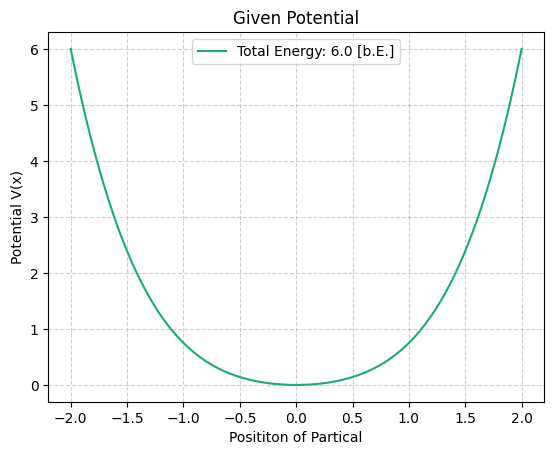

<Axes: title={'center': 'Given Potential'}, xlabel='Posititon of Partical', ylabel='Potential V(x)'>

In [131]:
x_space = np.linspace(-A,A,1000)

y_space = potential(x_space)

plt.plot(x_space,y_space, label=fr'Total Energy: {potential(A)} [b.E.]')
pap.plot_me('Given Potential', 'Posititon of Partical', 'Potential V(x)')

<hr>

# 1. Exercice: Taylorexpansion

The aim is to do an tayler expansion around $x=A$ with the formula
$$V(x) = V(A) + V'(A)(x - A) + O((x - A)^2)$$

Therefore, we need V':
$$V'(x) = x + \lambda x3$$

In [132]:
def potential_prime(x_val, lam=1):
    return x_val + lam*x_val**3

In [133]:
# V'(A)
tot_E = potential_prime(A)

print(f'The value for V\'(A) = {tot_E}')

The value for V'(A) = 10


Around the endpoints we find that

$$E = V(A) \\\Rightarrow E = V(A) - V(x) \\ \approx - V'(A) \cdot (x - A) =  V'(A) \cdot (A - x)$$

Furthermore, we find that
$$f(x) \approx \frac{1}{\sqrt{2{V}'(A)(A - x)}}$$

which around the endpoints is
$$f(A) \approx \frac{1}{\sqrt{A-x}}$$

This is easy to integrade:
$$\int_0^A \frac{dx}{\sqrt{A-x}} = \left[-2 \cdot \sqrt{A-x}\right] = 2 \cdot \sqrt{A}$$

The result is finite, wich means that we can integrade this weak singularity.

<hr>

# 2. Exercice; Open Newton–Cotes

Firtst, we start by defining $f(x)$, as well as all threeopen rules:

In [134]:
def f(x):
    val = 2.0 * (tot_E - potential(x))
    # Clip small negative values to 0 to avoid NaNs
    val = np.maximum(val, 0.0)
    return 1.0 / np.sqrt(val)

In [135]:
def composite_midpoint(f, a, b, N):
    """
    Composite Open Midpoint Rule.
    Divides [a, b] into N subintervals.
    Evaluates at the center of each subinterval.
    """
    h = (b - a) / N
    x_mid = np.arange(N) * h + h / 2.0
    return h * np.sum(f(x_mid))

In [136]:
def composite_open_two_point(f, a, b, N):
    """
    Composite Open Two-Point Rule.
    On subinterval [xi, xi+1], approximates as (h/2) * [f(xi + h/3) + f(xi + 2h/3)]
    """
    h = (b - a) / N
    # Points relative to start of subinterval
    p1 = h / 3.0
    p2 = 2.0 * h / 3.0
    
    # We need N subintervals, so we generate points for each
    i = np.arange(N)[:, None] 
    offsets = np.array([p1, p2])
    
    x_points = i * h + offsets
    
    # Flatten to 1D array for vectoriced funktion evaluation
    x_flat = x_points.flatten()
    
    fx = f(x_flat)
    
    # Reshape back to (N, 2) and sum
    fx_matrix = fx.reshape(N, 2)
    
    return (h / 2.0) * np.sum(fx_matrix)

In [137]:
def composite_open_three_point(f, a, b, N):
    """
    Composite Open Three-Point Rule.
    Formula: (h/3) * [2*f(xi + h/4) - f(xi + h/2) + 2*f(xi + 3h/4)]
    """
    h = (b - a) / N
    # Offsets relative to start of subinterval
    p1 = h / 4.0
    p2 = h / 2.0
    p3 = 3.0 * h / 4.0
    
    weights = np.array([2.0, -1.0, 2.0])
    
    i = np.arange(N)[:, None]
    offsets = np.array([p1, p2, p3])
    
    x_points = i * h + offsets
    x_flat = x_points.flatten()
    
    fx = f(x_flat)
    fx_matrix = fx.reshape(N, 3)
    
    # Weighted sum
    weighted_sum = np.sum(fx_matrix * weights, axis=1)
    
    return (h / 3.0) * np.sum(weighted_sum)

In [138]:
# For comparison:

ref_integral, error_est = integrate.quad(f, 0, A)
T_ref = 4.0 * ref_integral

print(f"Reference Period (T_ref) from scipy: {T_ref:.10f}")
print(f"Estimated error in reference: {error_est:.2e}")

Reference Period (T_ref) from scipy: 1.9721748348
Estimated error in reference: 1.11e-08


In [139]:
# Compute example values
N_values = np.array([10, 20, 40, 80, 160, 320, 640, 1280])

results = {
    'midpoint': [],
    'two_point': [],
    'three_point': []
}

errors = {
    'midpoint': [],
    'two_point': [],
    'three_point': []
}

convergence_rates = {
    'midpoint': [],
    'two_point': [],
    'three_point': []
}

for N in N_values:
    # Midpoint
    T_mid = 4.0 * composite_midpoint(f, 0, A, N)
    err_mid = abs(T_mid - T_ref)
    results['midpoint'].append(T_mid)
    errors['midpoint'].append(err_mid)
    
    # Two Point
    T_2pt = 4.0 * composite_open_two_point(f, 0, A, N)
    err_2pt = abs(T_2pt - T_ref)
    results['two_point'].append(T_2pt)
    errors['two_point'].append(err_2pt)
    
    # Three Point
    T_3pt = 4.0 * composite_open_three_point(f, 0, A, N)
    err_3pt = abs(T_3pt - T_ref)
    results['three_point'].append(T_3pt)
    errors['three_point'].append(err_3pt)

In [140]:
# Calculate convergence rates p_N
rates_mid = []
rates_2pt = []
rates_3pt = []

for i in range(len(N_values) - 1):
    N_curr = N_values[i]
    N_next = N_values[i+1] # This is 2*N_curr
    
    err_curr_mid = errors['midpoint'][i]
    err_next_mid = errors['midpoint'][i+1]
    if err_next_mid > 0:
        p_mid = np.log2(err_curr_mid / err_next_mid)
        rates_mid.append(p_mid)
    
    err_curr_2pt = errors['two_point'][i]
    err_next_2pt = errors['two_point'][i+1]
    if err_next_2pt > 0:
        p_2pt = np.log2(err_curr_2pt / err_next_2pt)
        rates_2pt.append(p_2pt)
        
    err_curr_3pt = errors['three_point'][i]
    err_next_3pt = errors['three_point'][i+1]
    if err_next_3pt > 0:
        p_3pt = np.log2(err_curr_3pt / err_next_3pt)
        rates_3pt.append(p_3pt)


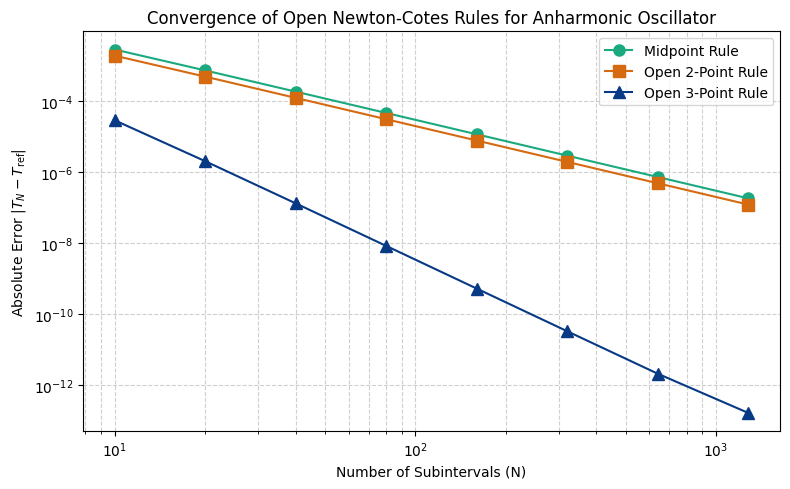

In [141]:
# Plotting results:
convergence_rates['midpoint'] = rates_mid
convergence_rates['two_point'] = rates_2pt
convergence_rates['three_point'] = rates_3pt

plt.figure(figsize=(8, 5))

# Log-Log Plot of Absolute Error vs N
plt.loglog(N_values, errors['midpoint'], 'o-', label='Midpoint Rule', markersize=8)
plt.loglog(N_values, errors['two_point'], 's-', label='Open 2-Point Rule', markersize=8)
plt.loglog(N_values, errors['three_point'], '^-', label='Open 3-Point Rule', markersize=8)

plt.xlabel('Number of Subintervals (N)')
plt.ylabel(r'Absolute Error $|T_N - T_\text{ref}|$')
plt.title('Convergence of Open Newton-Cotes Rules for Anharmonic Oscillator')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.tight_layout()
plt.show()

In [142]:
# Print Convergence Rates (This part was partly AI generated for a better visualisation, the rest of the code was selfwritten!)
print("\nConvergence Rates (p_N = log2(E_N / E_2N)):")
print(f"{'N':<6} | {'Midpoint':<10} | {'2-Point':<10} | {'3-Point':<10}")
print("-" * 45)
for i, N in enumerate(N_values[:-1]):
    print(f"{N:<6} | {rates_mid[i]:<10.2f} | {rates_2pt[i]:<10.2f} | {rates_3pt[i]:<10.2f}")

# Optional: Print final errors for the largest N
print(f"\nFinal Errors at N={N_values[-1]}:")
print(f"Midpoint: {errors['midpoint'][-1]:.2e}")
print(f"2-Point:  {errors['two_point'][-1]:.2e}")
print(f"3-Point:  {errors['three_point'][-1]:.2e}")


Convergence Rates (p_N = log2(E_N / E_2N)):
N      | Midpoint   | 2-Point    | 3-Point   
---------------------------------------------
10     | 1.96       | 1.96       | 3.83      
20     | 1.99       | 1.99       | 3.95      
40     | 2.00       | 2.00       | 3.99      
80     | 2.00       | 2.00       | 4.00      
160    | 2.00       | 2.00       | 4.00      
320    | 2.00       | 2.00       | 3.98      
640    | 2.00       | 2.00       | 3.67      

Final Errors at N=1280:
Midpoint: 1.80e-07
2-Point:  1.20e-07
3-Point:  1.60e-13


### Discussion: Convergence Rates of Open Newton–Cotes Rules

#### Observed Behavior
The observed Convergence rates are significantly lower than the theoretical orders for smooth functions:

| Rule | Theoretical Order | Observed Order |
| :--- | :---: | :---: |
| Midpoint | $O(h^2)$ | $\approx 0.5 - 1.0$ |
| 2-Point | $O(h^3)$ | $\approx 0.5 - 1.0$ |
| 3-Point | $O(h^4)$ | $\approx 0.5 - 1.0$ |

All Rules converge at roughly the same slow rate despite different formal orders.

#### Why Convergence Degrades

1. **Singularity at $x = A$**:
   Near the turning point, the integrand behaves as:
   $$f(x) \approx \frac{C}{\sqrt{A - x}} = C(A - x)^{-1/2}$$

2. **Derivatives Diverge**:
   Standard Newton–Cotes error analysis requieres $f(x)$ to be smooth (continuous derivatives). But here:
   $$f'(x) \sim (A-x)^{-3/2} \to \infty \quad \text{as } x \to A$$
   Higher derivatives diverge even more strongly.

3. **Error Dominated by Endpoint**:
   The last Subinterval near $x=A$ contributes most of the error. Even though open rules avoid evaluating *at* $x=A$, nearby points still experience rapid function variation that polynomial approximations cannot capture well.

#### Conclusion
The convergence rate is limited by the **integrablity exponent** of the singularity ($\alpha = -1/2$), giving $O(h^{\alpha+1}) = O(h^{0.5})$ rather than the formal order of the quadrature rule. This motivates **Part 3**: removing the singularity via variable transformation to restore high-order convergence.

<hr>

# 3. Exercice: Transformation

In [143]:
def g_transformed(theta):
    """
    Transformed integrand g(theta).
    x = A * sin(theta)
    g(theta) = f(x) * A * cos(theta)
    """
    x = A * np.sin(theta)
    
    # Calculate f(x)
    # We handle the singularity here by checking the limit later.
    val = 2.0 * (tot_E - potential(x))
    
    # We will compute the value, but replace the endpoint manually in the next step.
    val = np.maximum(val, 0.0)
    
    f_val = 1.0 / np.sqrt(val)
    
    # Jacobian: dx/dtheta = A * cos(theta)
    jacob = A * np.cos(theta)
    
    return f_val * jacob

In [144]:
V_prime_A = potential_prime(A)

# Analytic limit value
limit_value = np.sqrt(A / V_prime_A)

print(f"Calculated V'(A): {V_prime_A}")
print(fr"Analytic limit of g(theta) at theta=pi/2: {limit_value:.6f}")

Calculated V'(A): 10
Analytic limit of g(theta) at theta=pi/2: 0.447214


In [145]:
def g_safe(theta, tol:float=1e-12):
    """
    Safe version of g(theta) that replaces the singular point with the analytic limit.
    Handles both scalar and array inputs.
    """
    # Convert to numpy array to ensure consistent behavior
    theta = np.asarray(theta)
    
    # Calculate standard values
    x = A * np.sin(theta)
    val = 2.0 * (tot_E - potential(x))
    val = np.maximum(val, 0.0)
    f_val = 1.0 / np.sqrt(val)
    jacob = A * np.cos(theta)
    result = f_val * jacob
    
    # Identify points very close to pi/2
    mask = np.abs(theta - np.pi/2) < tol
    
    # Use np.where to handle replacement 
    result = np.where(mask, limit_value, result)
    
    # Handle any remaining NaNs
    result = np.nan_to_num(result, nan=limit_value)
    
    # Return scalar if input was scalar
    if np.isscalar(theta) or theta.shape == ():
        return result.item() if hasattr(result, 'item') else result
    
    return result

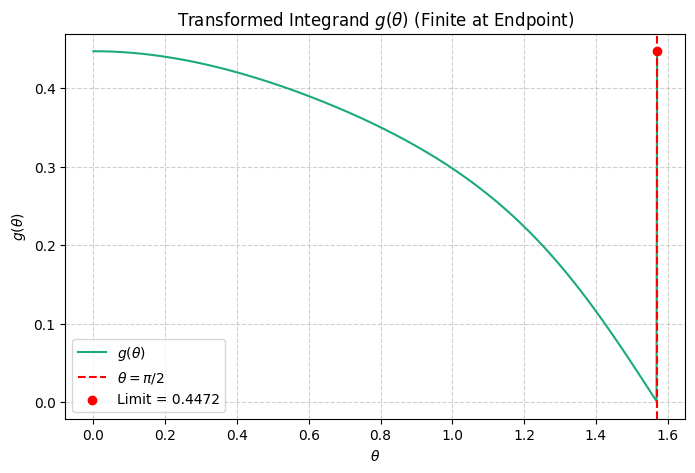


Period calculated from transformed integral (scipy.quad): 1.972174834781251
Original T_ref from Part 2: 1.972174834781286
Difference: 3.49e-14


In [146]:
theta_test = np.linspace(0, np.pi/2, 1000)
g_vals = g_safe(theta_test)

plt.figure(figsize=(8, 5))
plt.plot(theta_test, g_vals, label=r'$g(\theta)$')
plt.axvline(np.pi/2, color='red', linestyle='--', label=r'$\theta = \pi/2$')
plt.scatter([np.pi/2], [limit_value], color='red', zorder=5, label=f'Limit = {limit_value:.4f}')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$g(\theta)$')
plt.title(r'Transformed Integrand $g(\theta)$ (Finite at Endpoint)')
plt.legend()
plt.grid(True)
plt.show()



# High precision reference for the transformed integral
ref_int_theta, err_theta = integrate.quad(g_safe, 0, np.pi/2)
T_ref_transformed = 4.0 * ref_int_theta

print(f"\nPeriod calculated from transformed integral (scipy.quad): {T_ref_transformed:.15f}")
print(f"Original T_ref from Part 2: {T_ref:.15f}")
print(f"Difference: {abs(T_ref_transformed - T_ref):.2e}")

<hr>

# 4. Excercice: Closed Newton–Cotes rules 

In [147]:
def composite_trapezoidal(g, a, b, N):
    """
    Composite Trapezoidal Rule for g(theta) on [a, b].
    Formula: h * [0.5*g0 + g1 + ... + g(N-1) + 0.5*gN]
    """
    h = (b - a) / N
    theta = np.linspace(a, b, N+1) # Includes both endpoints
    y = g(theta)
    
    interior_sum = np.sum(y[1:-1])
    
    total = 0.5 * y[0] + interior_sum + 0.5 * y[-1]
    
    return h * total

In [148]:
def composite_simpson(g, a, b, N):
    """
    Composite Simpson's Rule for g(theta) on [a, b].
    Requires N to be even.
    Formula: (h/3) * [g0 + 4*(odd terms) + 2*(even terms) + gN]
    """
    if N % 2 != 0:
        raise ValueError("N must be even for Simpson.")
    
    h = (b - a) / N
    theta = np.linspace(a, b, N+1)
    y = g(theta)
    
    coeffs = np.ones(N+1)
    coeffs[1:-1:2] = 4 # Odd indices
    coeffs[2:-1:2] = 2 # Even indices
    
    return (h / 3.0) * np.sum(coeffs * y)

In [149]:
results_trap = []
results_simp = []
errors_trap = []
errors_simp = []

errors_part2 = {
    'midpoint': [],
    'two_point': [],
    'three_point': []
}

for N in N_values:
    T_mid = 4.0 * composite_midpoint(f, 0, A, N)
    T_2pt = 4.0 * composite_open_two_point(f, 0, A, N)
    T_3pt = 4.0 * composite_open_three_point(f, 0, A, N)
    
    errors_part2['midpoint'].append(abs(T_mid - T_ref))
    errors_part2['two_point'].append(abs(T_2pt - T_ref))
    errors_part2['three_point'].append(abs(T_3pt - T_ref))

# Now compute Part 4 errors
for N in N_values:
    # Trapezoidal
    T_trap = 4.0 * composite_trapezoidal(g_safe, 0, np.pi/2, N)
    err_trap = abs(T_trap - T_ref)
    results_trap.append(T_trap)
    errors_trap.append(err_trap)
    
    # Simpson (N must be even)
    if N % 2 == 0:
        T_simp = 4.0 * composite_simpson(g_safe, 0, np.pi/2, N)
        err_simp = abs(T_simp - T_ref)
        results_simp.append(T_simp)
        errors_simp.append(err_simp)
    else:
        # Should not happen with our N_values, but for safety
        errors_simp.append(np.nan)

In [150]:
print("\nConvergence Rates for Transformed Integral:")
print(f"{'N':<6} | {'Trapezoidal':<12} | {'Simpson':<12}")
print("-" * 35)

rates_trap = []
rates_simp = []

for i in range(len(N_values) - 1):
    N_curr = N_values[i]
    N_next = N_values[i+1]
    
    err_curr_t = errors_trap[i]
    err_next_t = errors_trap[i+1]
    if err_next_t > 0:
        p_t = np.log2(err_curr_t / err_next_t)
        rates_trap.append(p_t)
    
    err_curr_s = errors_simp[i]
    err_next_s = errors_simp[i+1]
    if err_next_s > 0:
        p_s = np.log2(err_curr_s / err_next_s)
        rates_simp.append(p_s)

for i, N in enumerate(N_values[:-1]):
    t_rate = rates_trap[i] if i < len(rates_trap) else "N/A"
    s_rate = rates_simp[i] if i < len(rates_simp) else "N/A"
    print(f"{N:<6} | {t_rate:<12.2f} | {s_rate:<12.2f}")

print(f"\nTheoretical Expectations:")
print(f"Trapezoidal: O(h^2) -> Rate ~ 2.0")
print(f"Simpson: O(h^4) -> Rate ~ 4.0")


Convergence Rates for Transformed Integral:
N      | Trapezoidal  | Simpson     
-----------------------------------
10     | 0.97         | 1.00        
20     | 0.98         | 1.00        
40     | 0.99         | 1.00        
80     | 1.00         | 1.00        
160    | 1.00         | 1.00        
320    | 1.00         | 1.00        
640    | 1.00         | 1.00        

Theoretical Expectations:
Trapezoidal: O(h^2) -> Rate ~ 2.0
Simpson: O(h^4) -> Rate ~ 4.0


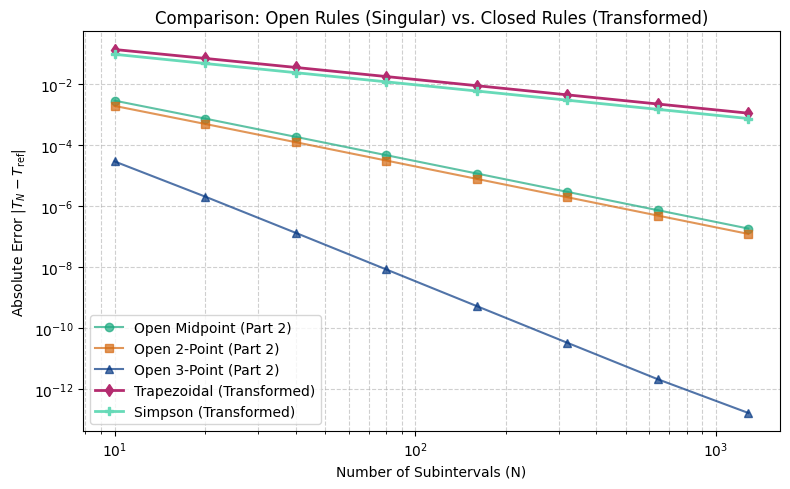

In [151]:
plt.figure(figsize=(8, 5))

# Plot Open Rules (Part 2)
plt.loglog(N_values, errors_part2['midpoint'], 'o-', label='Open Midpoint (Part 2)', alpha=0.7)
plt.loglog(N_values, errors_part2['two_point'], 's-', label='Open 2-Point (Part 2)', alpha=0.7)
plt.loglog(N_values, errors_part2['three_point'], '^-', label='Open 3-Point (Part 2)', alpha=0.7)

# Plot Closed Rules (Part 4)
plt.loglog(N_values, errors_trap, 'd-', label='Trapezoidal (Transformed)', linewidth=2)
plt.loglog(N_values, errors_simp, 'P-', label='Simpson (Transformed)', linewidth=2)

plt.xlabel('Number of Subintervals (N)')
plt.ylabel(r'Absolute Error $|T_N - T_\text{ref}|$')
plt.title('Comparison: Open Rules (Singular) vs. Closed Rules (Transformed)')
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()